In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- QUTIP IMPORTS ---
import qutip as qt

# --- QISKIT IMPORTS ---
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ==========================================
# 0. SIMULATION PARAMETERS
# ==========================================
total_time = 4.0       # Total simulation time
num_steps = 101        # Number of time points (100 intervals)
time_steps = np.linspace(0, total_time, num_steps)
dt = total_time / (num_steps - 1)  # Exact time step

# Physics parameters (in arbitrary units where ħ = 1)
omega_0 = 2.0          # Initial Hamiltonian strength (prepares |0>)
Omega = 3.0            # Quench Hamiltonian X-component strength
Delta = 1.5            # Quench Hamiltonian Z-component strength

print(f"Quantum Quench Benchmark: dt = {dt:.6f}, Total Time = {total_time}")
print(f"Quench Hamiltonian: H = ({Omega}/2)σ_x + ({Delta}/2)σ_z")

Quantum Quench Benchmark: dt = 0.040000, Total Time = 4.0
Quench Hamiltonian: H = (3.0/2)σ_x + (1.5/2)σ_z


In [3]:
# ==========================================
# 1. QUTIP SIMULATION (Continuous)
# ==========================================

# Initial state: Ground state of H_0 = (omega_0 / 2) * sigma_z is |0>
psi0 = qt.basis(2, 0)

# Quench Hamiltonian
H_quench = 0.5 * Omega * qt.sigmax() + 0.5 * Delta * qt.sigmaz()

# Observable: sigma_z
sz_op = qt.sigmaz()

# Solve the Schrödinger equation (no collapse operators for pure unitary quench)
# Using mesolve for consistency, but sesolve is also perfectly fine here.
qutip_result = qt.mesolve(H_quench, psi0, time_steps, [], [sz_op])
qutip_exp_sz = qutip_result.expect[0]

print("✅ QuTiP simulation completed.")

✅ QuTiP simulation completed.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [4]:
# ==========================================
# 2. QISKIT SIMULATION (Discrete Trotterized)
# ==========================================
qiskit_exp_sz = []

# Initialize the AerSimulator with density matrix method for exact expectation values
simulator = AerSimulator(method='density_matrix')

# Pauli Z matrix for expectation value calculation
sz_matrix = np.array([[1, 0], [0, -1]], dtype=complex)

for step in range(num_steps):
    qc = QuantumCircuit(1)
    
    # Initial state is already |0>, so no preparation gate is needed.
    
    # Apply 'step' layers of Trotterized time evolution
    # First-order Trotter: U(dt) ≈ R_z(Delta * dt) * R_x(Omega * dt)
    # Note: The order of gates introduces the O(dt^2) Trotter error per step.
    for _ in range(step):
        qc.rz(Delta * dt, 0)
        qc.rx(Omega * dt, 0)
        
    # Save the final density matrix
    qc.save_density_matrix()
    
    # Execute
    result = simulator.run(qc).result()
    rho = result.data()['density_matrix']
    
    # Calculate <σ_z> = Tr(ρ * σ_z)
    exp_sz = np.real(np.trace(rho.data @ sz_matrix))
    qiskit_exp_sz.append(exp_sz)

print("✅ Qiskit simulation completed.")

✅ Qiskit simulation completed.



--- BENCHMARK RESULTS ---
Max Deviation (QuTiP vs Qiskit): 1.547979e-03
Average Deviation:               6.072538e-04
Note: Error scales with O(dt) due to first-order Trotterization.


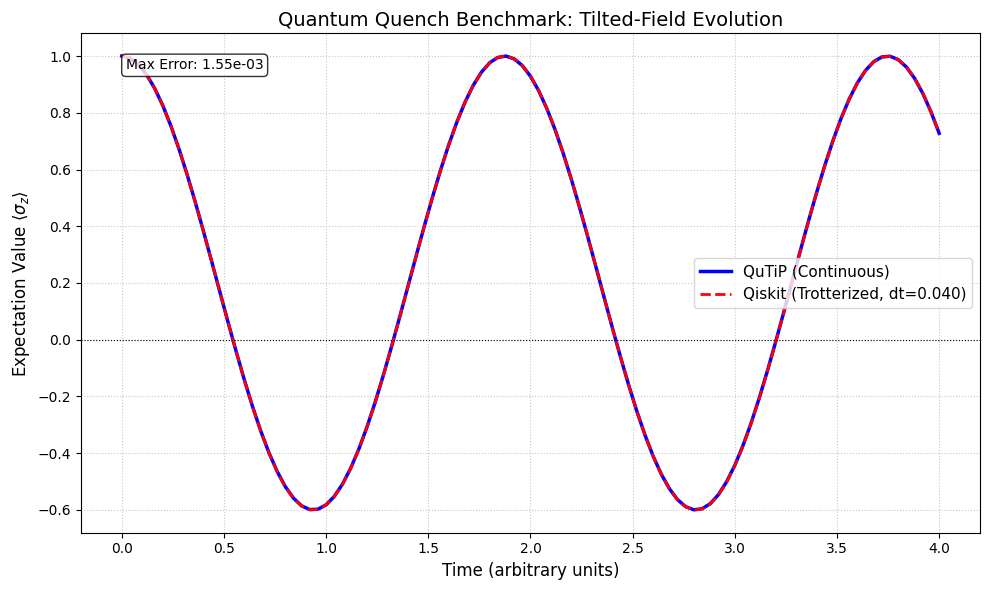

In [5]:
# ==========================================
# 3. ACCURACY BENCHMARK & PLOTTING
# ==========================================

# Calculate absolute error at each time step
errors = np.abs(np.array(qutip_exp_sz) - np.array(qiskit_exp_sz))
max_error = np.max(errors)
avg_error = np.mean(errors)

print(f"\n--- BENCHMARK RESULTS ---")
print(f"Max Deviation (QuTiP vs Qiskit): {max_error:.6e}")
print(f"Average Deviation:               {avg_error:.6e}")
print("Note: Error scales with O(dt) due to first-order Trotterization.")

# Plotting
plt.figure(figsize=(10, 6))

# Plot QuTiP (Continuous baseline)
plt.plot(time_steps, qutip_exp_sz, 'b-', label='QuTiP (Continuous)', linewidth=2.5)

# Plot Qiskit (Discrete)
plt.plot(time_steps, qiskit_exp_sz, 'r--', label=f'Qiskit (Trotterized, dt={dt:.3f})', linewidth=2)

# Formatting
plt.title('Quantum Quench Benchmark: Tilted-Field Evolution', fontsize=14)
plt.xlabel('Time (arbitrary units)', fontsize=12)
plt.ylabel(r'Expectation Value $\langle \sigma_z \rangle$', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

# Add error annotation to the plot
plt.text(0.05, 0.95, f'Max Error: {max_error:.2e}', transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()